In [87]:
import pandas as pd

In [88]:
df = pd.read_csv('cleaned_retail_1.csv')

In [90]:
df.shape

(534129, 8)

In [91]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,132565
Country,0


In [92]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534129 entries, 0 to 534128
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    534129 non-null  object        
 1   StockCode    534129 non-null  object        
 2   Description  534129 non-null  object        
 3   Quantity     534129 non-null  int64         
 4   InvoiceDate  534129 non-null  datetime64[ns]
 5   UnitPrice    534129 non-null  float64       
 6   CustomerID   401564 non-null  float64       
 7   Country      534129 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.6+ MB


In [94]:
customer_df = df.dropna(subset=["CustomerID"]).copy()
customer_df["CustomerID"] = customer_df["CustomerID"].astype(int)

In [95]:
customer_df.shape

(401564, 8)

In [96]:
customer_df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [97]:
customer_df.duplicated().sum()

np.int64(0)

In [98]:
customer_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,401564.000000,401564,401564.000000,401564.000000
mean,12.149911,2011-07-10 12:06:07.514567936,3.474410,15281.266797
min,-80995.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000
50%,5.000000,2011-07-29 15:32:30,1.950000,15145.000000
75%,12.000000,2011-10-20 11:58:00,3.750000,16788.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,249.512649,NaN,69.767501,1713.978947


In [99]:
customer_df[customer_df["Quantity"] < 0].shape

(8872, 8)

In [100]:
customer_df[customer_df["InvoiceNo"].astype(str).str.startswith("C")].shape

(8872, 8)

In [101]:
customer_df = customer_df[customer_df["Quantity"] > 0]

In [102]:
customer_df = customer_df[customer_df["UnitPrice"] > 0]

In [103]:
customer_df.shape

(392692, 8)

In [104]:
customer_df["TotalAmount"] = (
    customer_df["Quantity"] * customer_df["UnitPrice"]
)

In [105]:
customer_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [106]:
customer_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [107]:
print(customer_df["Country"].nunique())
print(customer_df["Country"].value_counts())

37
Country
United Kingdom          349203
Germany                   9025
France                    8326
EIRE                      7226
Spain                     2479
Netherlands               2359
Belgium                   2031
Switzerland               1841
Portugal                  1453
Australia                 1181
Norway                    1071
Italy                      758
Channel Islands            747
Finland                    685
Cyprus                     603
Sweden                     450
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     245
Unspecified                241
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         57
Lebanon                     

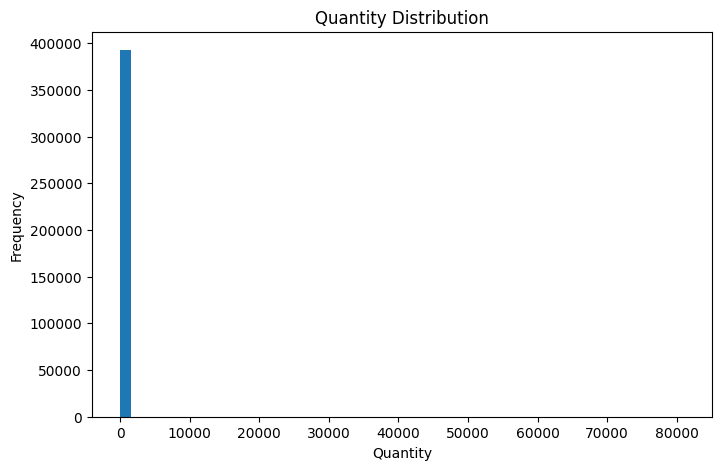

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(customer_df["Quantity"], bins=50)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

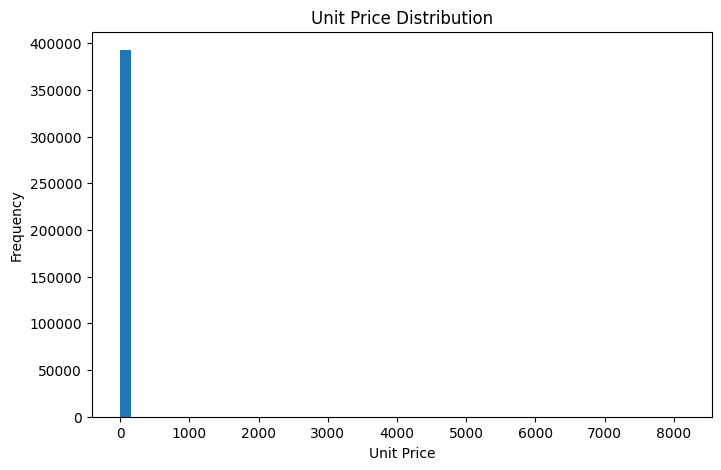

In [109]:
plt.figure(figsize=(8,5))
plt.hist(customer_df["UnitPrice"], bins=50)
plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

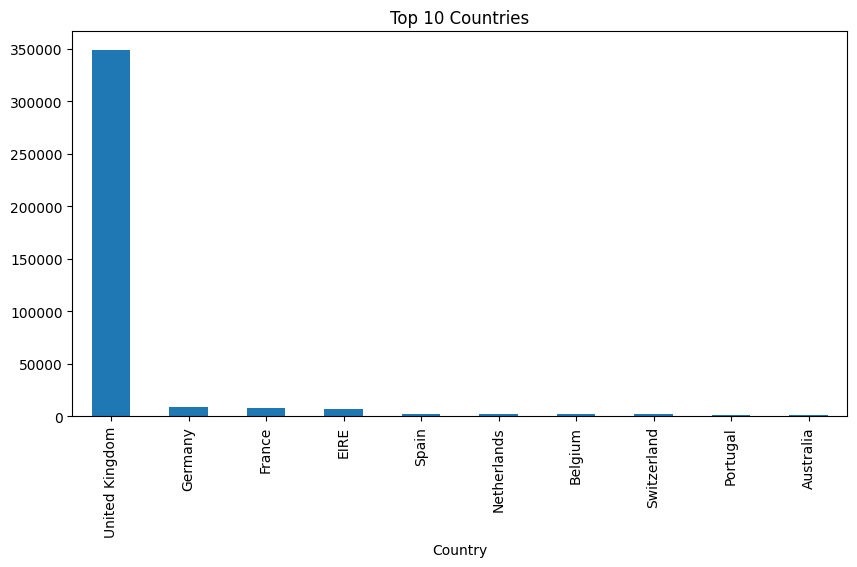

In [110]:
customer_df["Country"].value_counts().head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries")
plt.show()

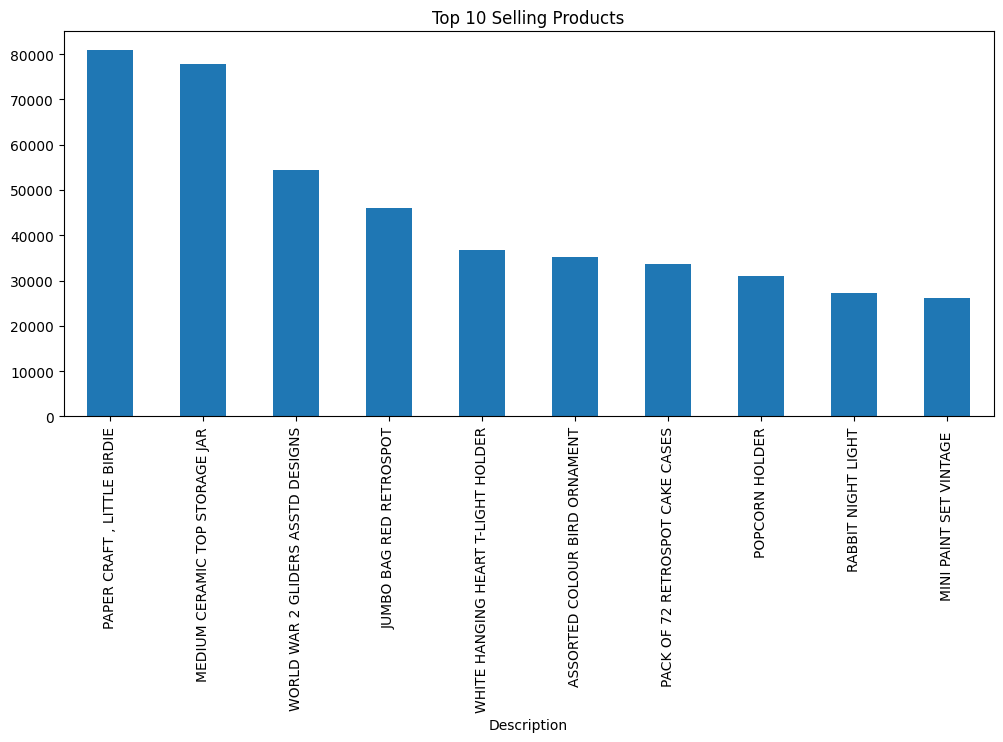

In [111]:
customer_df.groupby("Description")["Quantity"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10) \
    .plot(kind="bar", figsize=(12,5))

plt.title("Top 10 Selling Products")
plt.show()

In [112]:
customer_df["TotalAmount"] = customer_df["Quantity"] * customer_df["UnitPrice"]

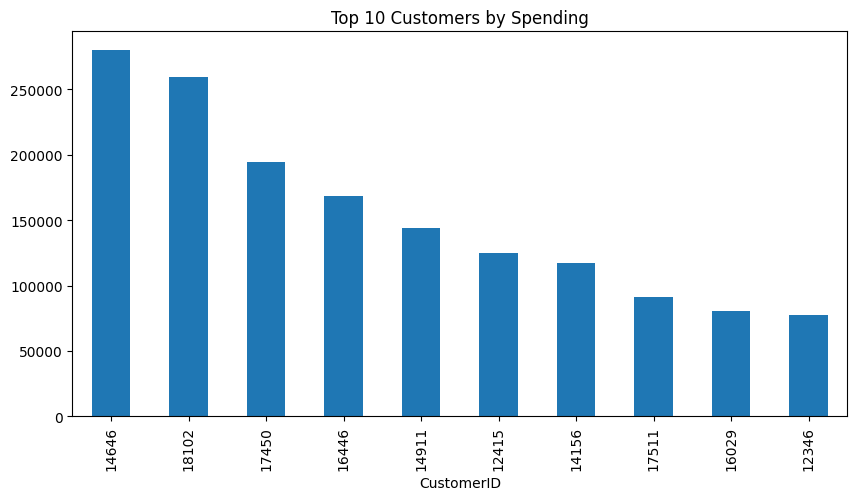

In [113]:
customer_df.groupby("CustomerID")["TotalAmount"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10) \
    .plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Customers by Spending")
plt.show()

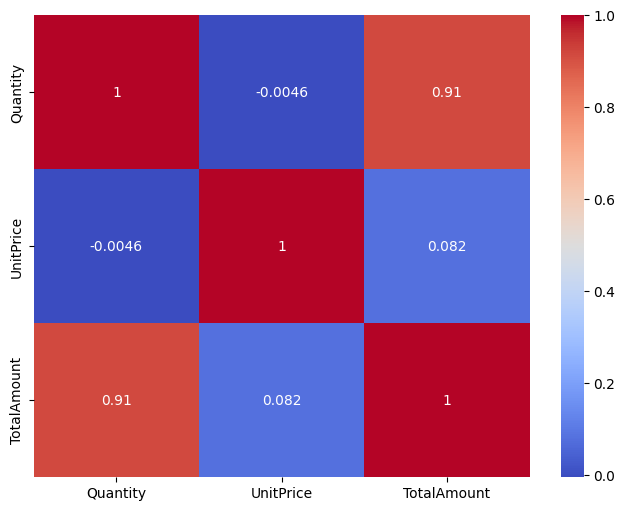

In [114]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    customer_df[["Quantity", "UnitPrice", "TotalAmount"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [115]:
customer_df["Month"] = customer_df["InvoiceDate"].dt.month

In [117]:
customer_df["Day"] = customer_df["InvoiceDate"].dt.day

In [118]:
customer_df["Hour"] = customer_df["InvoiceDate"].dt.hour

In [119]:
customer_df["Weekday"] = customer_df["InvoiceDate"].dt.day_name()

In [123]:
customer_df.sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Month,Day,Hour,Weekday
522361,580771,22185,SLATE TILE NATURAL HANGING,108,2011-12-06 10:58:00,0.79,16015,United Kingdom,85.32,12,6,10,Tuesday
74472,542605,22427,ENAMEL FLOWER JUG CREAM,2,2011-01-30 12:42:00,5.95,17796,United Kingdom,11.90,1,30,12,Sunday
81031,543193,22425,ENAMEL COLANDER CREAM,3,2011-02-04 12:18:00,4.95,13725,United Kingdom,14.85,2,4,12,Friday
263854,560305,20983,12 PENCILS TALL TUBE RED RETROSPOT,1,2011-07-18 10:49:00,0.85,16511,United Kingdom,0.85,7,18,10,Monday
114690,546237,20711,JUMBO BAG TOYS,10,2011-03-10 12:50:00,1.95,16625,United Kingdom,19.50,3,10,12,Thursday
516861,580555,21733,RED HANGING HEART T-LIGHT HOLDER,32,2011-12-05 10:18:00,2.55,14911,EIRE,81.60,12,5,10,Monday
107949,545649,72802A,ROSE SCENT CANDLE IN JEWELLED BOX,1,2011-03-04 13:14:00,4.25,14995,United Kingdom,4.25,3,4,13,Friday
190319,553507,23094,LE GRAND TRAY CHIC SET,2,2011-05-17 13:35:00,12.50,17220,United Kingdom,25.00,5,17,13,Tuesday
413292,572753,21169,YOU'RE CONFUSING ME METAL SIGN,6,2011-10-25 17:29:00,1.69,15856,United Kingdom,10.14,10,25,17,Tuesday
303100,563909,84536A,ENGLISH ROSE NOTEBOOK A7 SIZE,7,2011-08-21 12:36:00,0.42,15701,United Kingdom,2.94,8,21,12,Sunday


<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='YearMonth'>

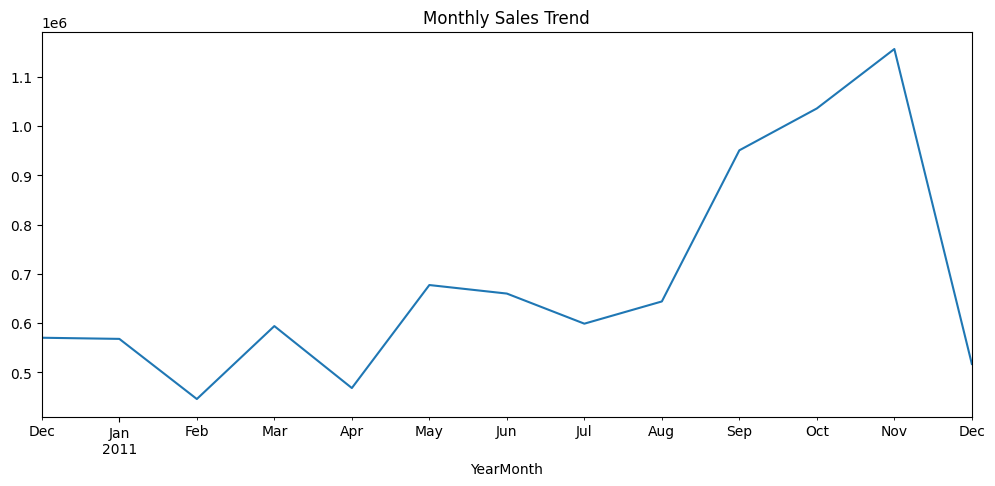

In [124]:
customer_df["YearMonth"] = customer_df["InvoiceDate"].dt.to_period("M")

monthly_sales = customer_df.groupby("YearMonth")["TotalAmount"].sum()

monthly_sales.plot(figsize=(12,5), title="Monthly Sales Trend")

<Axes: title={'center': 'Daily Sales Trend'}, xlabel='InvoiceDate'>

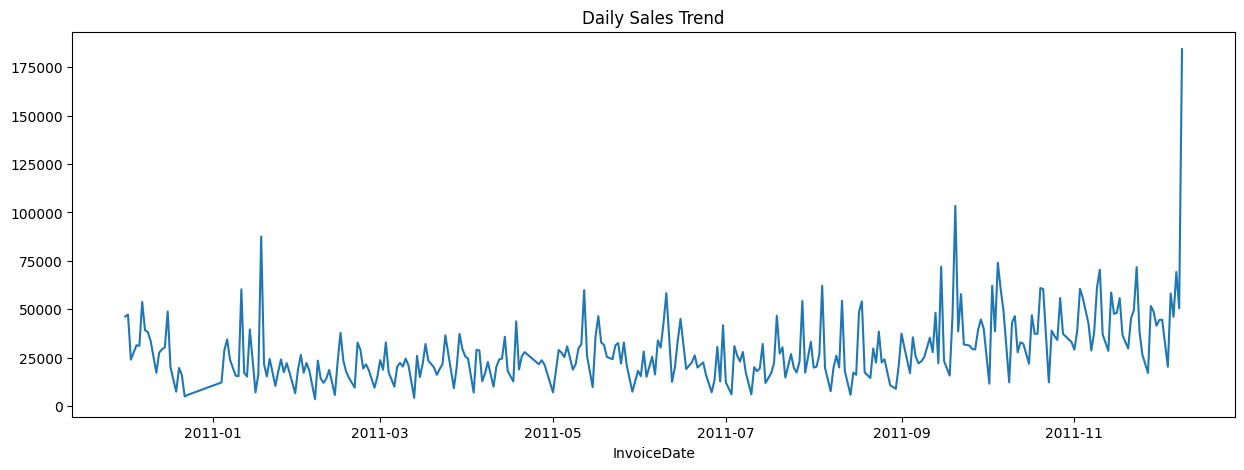

In [125]:
daily_sales = customer_df.groupby(
    customer_df["InvoiceDate"].dt.date
)["TotalAmount"].sum()

daily_sales.plot(figsize=(15,5), title="Daily Sales Trend")

<Axes: title={'center': 'Hourly Sales Trend'}, xlabel='InvoiceDate'>

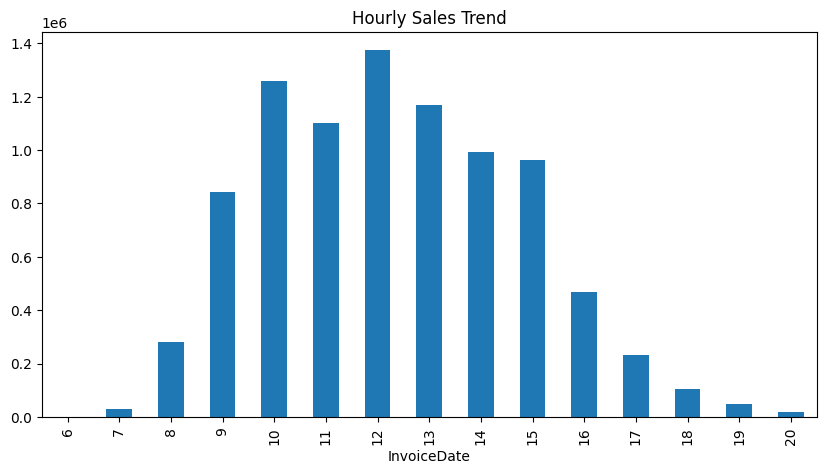

In [126]:
hourly_sales = customer_df.groupby(
    customer_df["InvoiceDate"].dt.hour
)["TotalAmount"].sum()

hourly_sales.plot(kind="bar", figsize=(10,5), title="Hourly Sales Trend")

<Axes: title={'center': 'Top 10 Revenue Countries'}, xlabel='Country'>

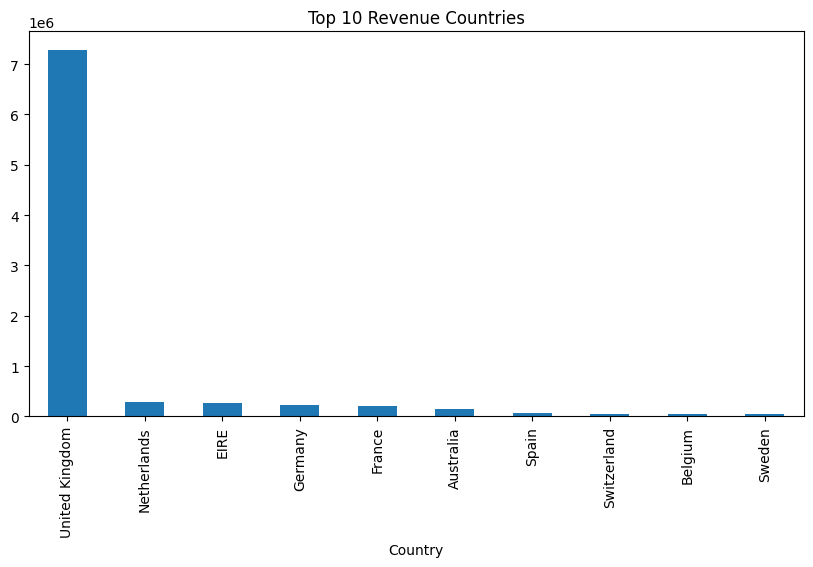

In [127]:
country_sales = (
    customer_df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10).plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Revenue Countries"
)

In [128]:
customer_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Month,Day,Hour,Weekday,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,12,1,8,Wednesday,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,1,8,Wednesday,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,12,1,8,Wednesday,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,1,8,Wednesday,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,1,8,Wednesday,2010-12


In [129]:
snapshot_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


In [130]:
rfm = customer_df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

In [131]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [132]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [133]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [134]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [135]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,5,115
12347,2,7,4310.00,5,5,5,555
12348,75,4,1797.24,2,4,4,244
12349,19,1,1757.55,4,1,4,414
12350,310,1,334.40,1,1,2,112


In [136]:
rfm["RFM_Score"].value_counts().head(20)

,count
RFM_Score,
555,347
111,183
455,177
121,153
112,127
444,118
122,90
544,85
233,83


In [137]:
def segment_customer(row):
    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "New Customers"

    elif r <= 2 and f >= 4:
        return "At Risk"

    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost Customers"

    else:
        return "Potential Customers"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [138]:
rfm["Segment"].value_counts()

,count
Segment,
Potential Customers,1202
Champions,957
Lost Customers,821
Loyal Customers,764
New Customers,319
At Risk,275


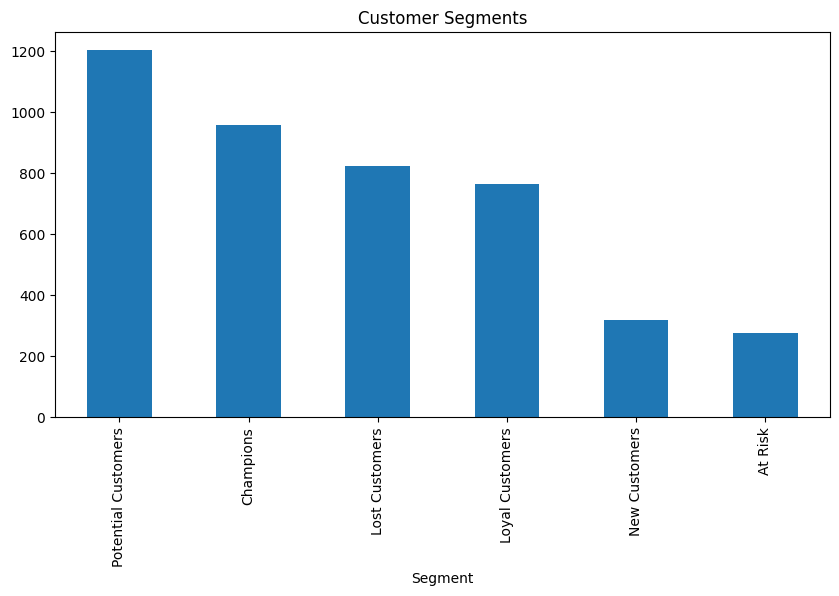

In [139]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(
    kind="bar",
    figsize=(10,5),
    title="Customer Segments"
)

plt.show()

In [140]:
segment_summary = rfm.groupby("Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

segment_summary


,Recency,Frequency,Monetary
Segment,,,
At Risk,137.08,4.89,1569.60
Champions,12.82,11.12,6051.87
Lost Customers,228.12,1.04,228.54
Loyal Customers,35.69,4.12,1827.90
New Customers,18.52,1.24,455.23
Potential Customers,108.98,1.79,777.51


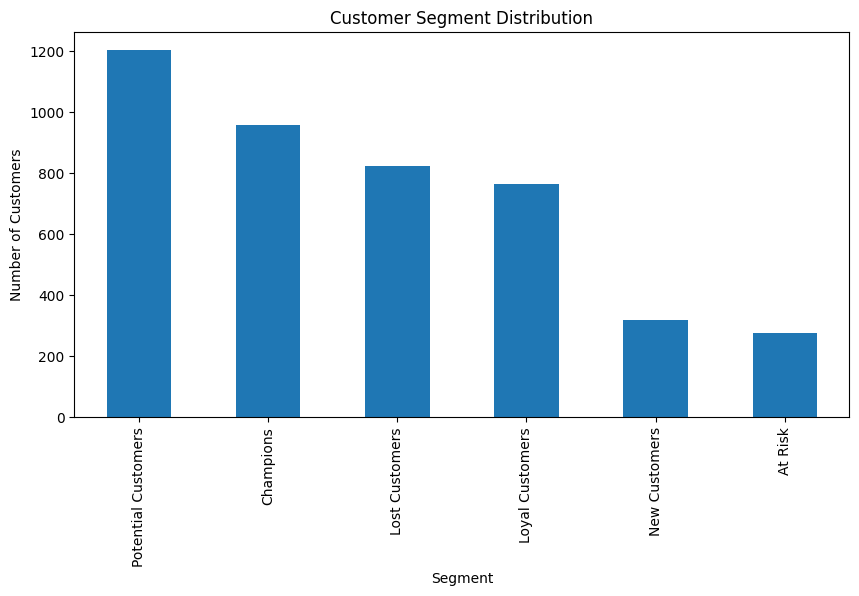

In [141]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(
    kind="bar",
    figsize=(10, 5),
    title="Customer Segment Distribution"
)

plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

In [142]:
from sklearn.preprocessing import StandardScaler

rfm_ml = rfm[["Recency", "Frequency", "Monetary"]].copy()

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_ml)

In [143]:
rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155]])

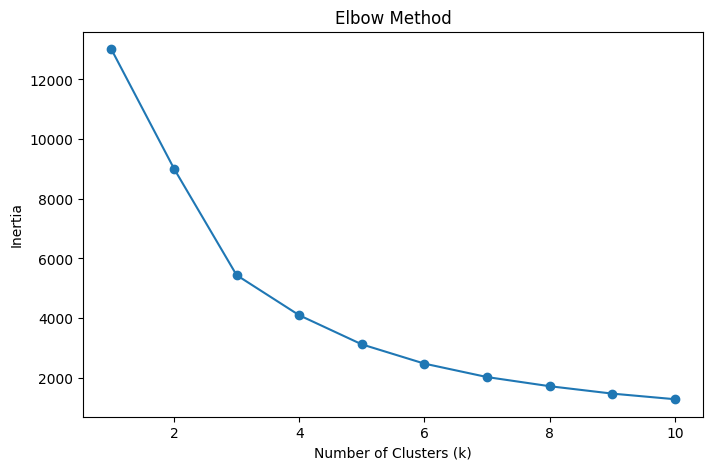

In [144]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [145]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [146]:
rfm["Cluster"].value_counts()

,count
Cluster,
1,3230
0,1082
2,26


In [147]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,247.11,1.58,629.66
1,41.45,4.67,1849.67
2,6.04,66.42,85826.08


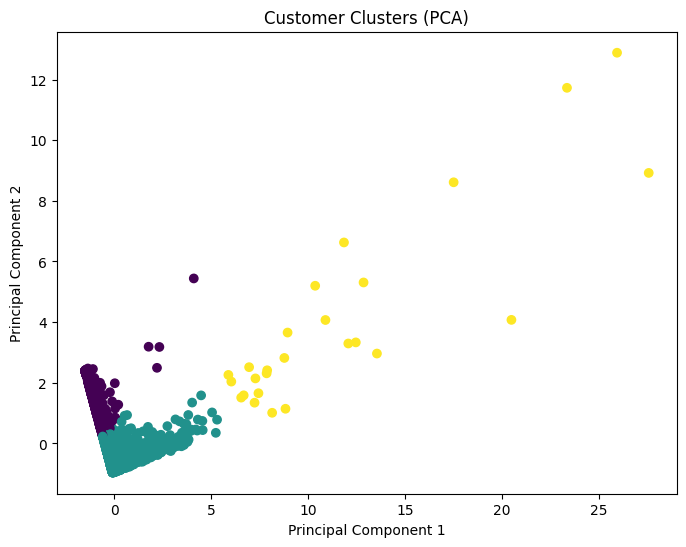

In [148]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    rfm_pca[:,0],
    rfm_pca[:,1],
    c=rfm["Cluster"]
)

plt.title("Customer Clusters (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [149]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm["Cluster"])
print(score)

0.5942233320872992


In [150]:
rfm.to_csv("customer_segments.csv", index=True)